# Skills Gap Analysis

## Objective
Identify current skills inventory vs. future skills needed to execute business strategy.

## Key Questions
1. What skills do we have today across the organization?
2. What emerging skills are most critical for growth?
3. Where are the biggest skills gaps?
4. Should we build (train) vs. buy (hire) for each skill gap?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Load data
print("Loading skills data...")
workforce = pd.read_csv('../data/current_workforce.csv')
skills = pd.read_csv('../data/employee_skills.csv')

print(f"Workforce: {len(workforce)} employees")
print(f"Skills data: {len(skills)} skill records")
print(f"Unique skills: {skills['skill'].nunique()}")

Loading skills data...
Workforce: 525 employees
Skills data: 2474 skill records
Unique skills: 86


## 1. Current Skills Inventory

In [2]:
# Top skills in the organization
skill_counts = skills.groupby('skill').agg({
    'employee_id': 'count',
    'proficiency': lambda x: (x.isin(['Advanced', 'Expert'])).sum()
}).rename(columns={'employee_id': 'total_employees', 'proficiency': 'advanced_experts'})

skill_counts['% of workforce'] = (skill_counts['total_employees'] / len(workforce) * 100).round(1)
skill_counts = skill_counts.sort_values('total_employees', ascending=False)

print("\nTOP 20 SKILLS IN ORGANIZATION")
print("="*70)
print(f"{'Skill':<30} {'Employees':<12} {'% Workforce':<15} {'Advanced+':<10}")
print("="*70)
for skill, row in skill_counts.head(20).iterrows():
    print(f"{skill:<30} {row['total_employees']:<12} {row['% of workforce']:<15} {row['advanced_experts']:<10}")
print("="*70)


TOP 20 SKILLS IN ORGANIZATION
Skill                          Employees    % Workforce     Advanced+ 
SQL                            116.0        22.1            57.0      
Machine Learning               91.0         17.3            37.0      
Account Management             84.0         16.0            41.0      
Python                         81.0         15.4            32.0      
TypeScript                     78.0         14.9            36.0      
Kubernetes                     77.0         14.7            40.0      
Node.js                        76.0         14.5            33.0      
AWS                            73.0         13.9            32.0      
Java                           71.0         13.5            28.0      
JavaScript                     69.0         13.1            35.0      
Docker                         66.0         12.6            31.0      
React                          60.0         11.4            35.0      
Git                            56.0         10

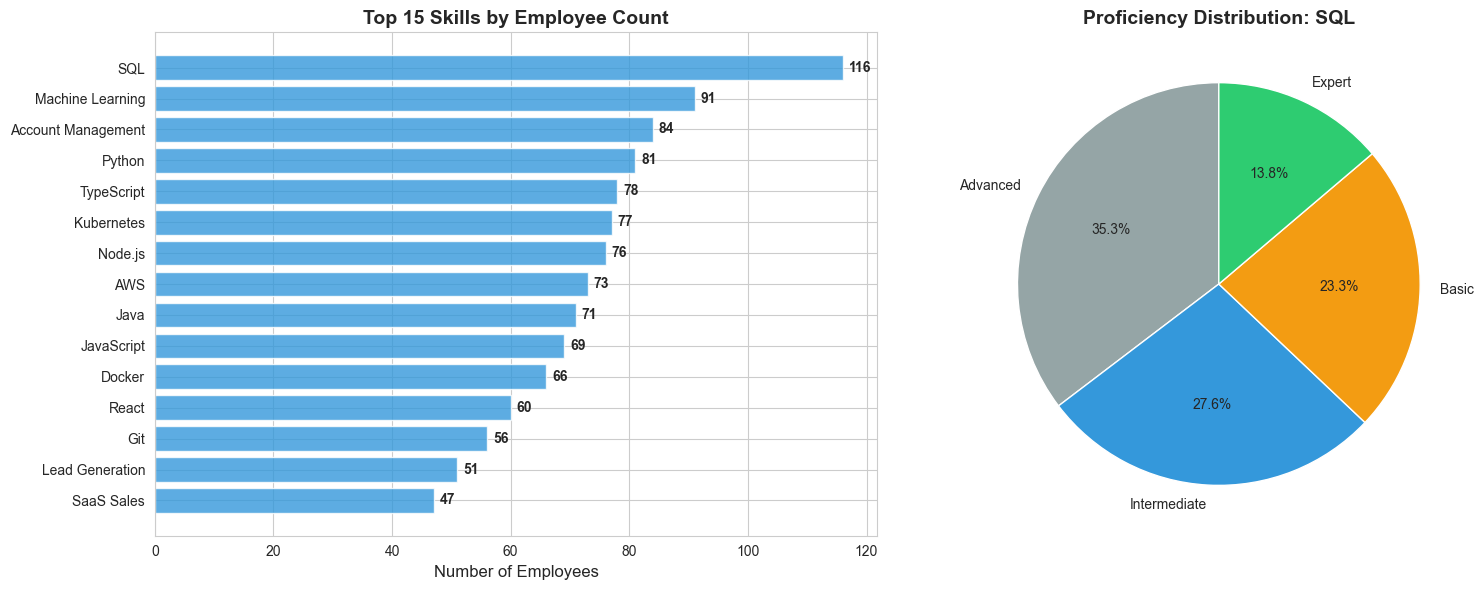

In [3]:
# Visualize top skills
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 skills by employee count
top_15 = skill_counts.head(15)
ax1.barh(range(len(top_15)), top_15['total_employees'], color='#3498db', alpha=0.8)
ax1.set_yticks(range(len(top_15)))
ax1.set_yticklabels(top_15.index)
ax1.set_xlabel('Number of Employees', fontsize=12)
ax1.set_title('Top 15 Skills by Employee Count', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# Add value labels
for i, val in enumerate(top_15['total_employees']):
    ax1.text(val + 1, i, str(val), va='center', fontweight='bold')

# Proficiency distribution for top skill
top_skill = top_15.index[0]
top_skill_data = skills[skills['skill'] == top_skill]
prof_counts = top_skill_data['proficiency'].value_counts()

colors = ['#95a5a6', '#3498db', '#f39c12', '#2ecc71']
ax2.pie(prof_counts, labels=prof_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax2.set_title(f'Proficiency Distribution: {top_skill}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Skills by Department

In [4]:
# Merge skills with workforce to get department
skills_with_dept = skills.merge(workforce[['employee_id', 'department']], on='employee_id')

# Top 5 skills per department
print("\nTOP 5 SKILLS PER DEPARTMENT")
print("="*70)

for dept in sorted(workforce['department'].unique()):
    dept_skills = skills_with_dept[skills_with_dept['department'] == dept]
    top_skills = dept_skills['skill'].value_counts().head(5)
    
    print(f"\n{dept}:")
    for i, (skill, count) in enumerate(top_skills.items(), 1):
        print(f"  {i}. {skill} ({count} employees)")

print("="*70)


TOP 5 SKILLS PER DEPARTMENT

Customer Success:
  1. Account Management (40 employees)
  2. CRM (40 employees)
  3. Upselling (39 employees)
  4. Customer Onboarding (39 employees)
  5. Training (39 employees)

Data:
  1. Tableau (20 employees)
  2. R (20 employees)
  3. BigQuery (18 employees)
  4. Power BI (17 employees)
  5. SQL (17 employees)

Engineering:
  1. TypeScript (78 employees)
  2. Machine Learning (78 employees)
  3. Kubernetes (77 employees)
  4. Node.js (76 employees)
  5. SQL (73 employees)

Finance:
  1. Accounting (16 employees)
  2. Excel (15 employees)
  3. Financial Reporting (14 employees)
  4. ERP Systems (14 employees)
  5. FP&A (13 employees)

HR:
  1. Employee Relations (12 employees)
  2. Benefits (12 employees)
  3. HR Analytics (11 employees)
  4. Compensation (10 employees)
  5. HRIS (10 employees)

Legal:
  1. Negotiation (7 employees)
  2. Compliance (6 employees)
  3. Employment Law (6 employees)
  4. Risk Management (6 employees)
  5. Corporate Law (

## 3. Emerging Skills Analysis

In [5]:
# Define emerging/future skills needed for strategy
emerging_skills = [
    'AI/ML', 'Blockchain', 'Cloud Architecture', 'Data Science',
    'Cybersecurity', 'DevOps', 'Product-Led Growth', 'Change Management'
]

# Current coverage of emerging skills
emerging_coverage = skills[skills['skill'].isin(emerging_skills)].groupby('skill').agg({
    'employee_id': 'count',
    'proficiency': lambda x: (x.isin(['Advanced', 'Expert'])).sum()
}).rename(columns={'employee_id': 'employees_with_skill', 'proficiency': 'advanced_experts'})

# Add missing emerging skills with zero count
for skill in emerging_skills:
    if skill not in emerging_coverage.index:
        emerging_coverage.loc[skill] = [0, 0]

emerging_coverage = emerging_coverage.sort_values('employees_with_skill', ascending=False)
emerging_coverage['% of workforce'] = (emerging_coverage['employees_with_skill'] / len(workforce) * 100).round(1)

print("\nEMERGING SKILLS COVERAGE")
print("="*70)
print(f"{'Skill':<25} {'Employees':<15} {'% Workforce':<15} {'Advanced+':<10}")
print("="*70)
for skill, row in emerging_coverage.iterrows():
    print(f"{skill:<25} {int(row['employees_with_skill']):<15} {row['% of workforce']:<15} {int(row['advanced_experts']):<10}")
print("="*70)


EMERGING SKILLS COVERAGE
Skill                     Employees       % Workforce     Advanced+ 
DevOps                    17              3.2             5         
AI/ML                     15              2.9             10        
Cybersecurity             13              2.5             2         
Blockchain                12              2.3             5         
Data Science              10              1.9             4         
Change Management         9               1.7             2         
Product-Led Growth        8               1.5             5         
Cloud Architecture        7               1.3             3         


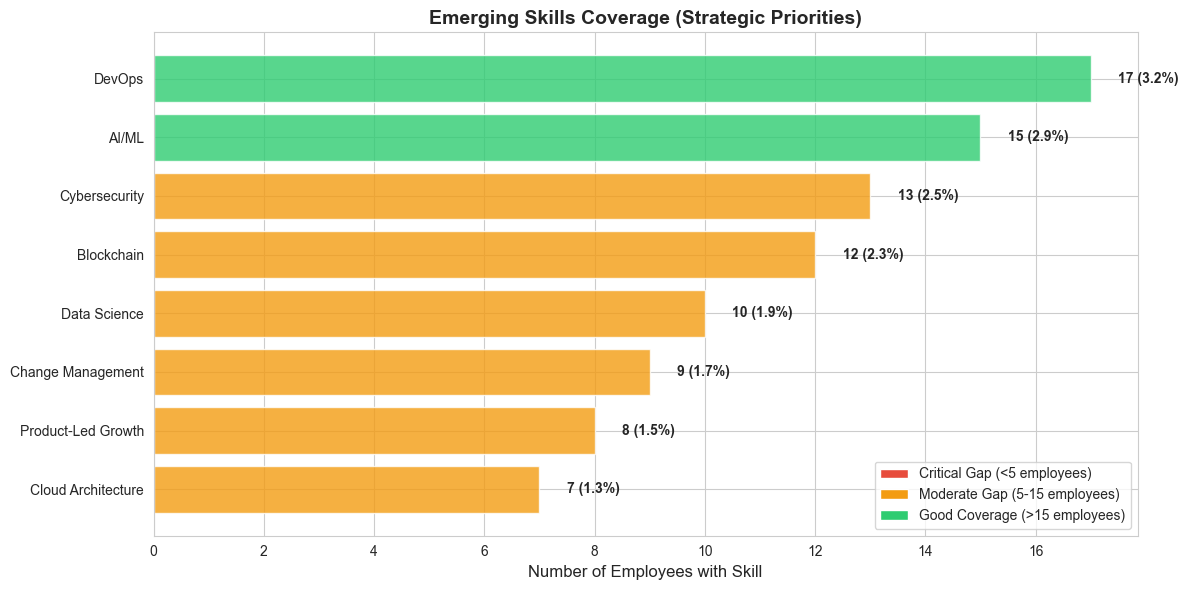

In [6]:
# Visualize emerging skills gap
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#e74c3c' if x < 5 else '#f39c12' if x < 15 else '#2ecc71' 
          for x in emerging_coverage['employees_with_skill']]

bars = ax.barh(range(len(emerging_coverage)), emerging_coverage['employees_with_skill'], 
               color=colors, alpha=0.8)
ax.set_yticks(range(len(emerging_coverage)))
ax.set_yticklabels(emerging_coverage.index)
ax.set_xlabel('Number of Employees with Skill', fontsize=12)
ax.set_title('Emerging Skills Coverage (Strategic Priorities)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels and % of workforce
for i, (idx, row) in enumerate(emerging_coverage.iterrows()):
    count = int(row['employees_with_skill'])
    pct = row['% of workforce']
    ax.text(count + 0.5, i, f"{count} ({pct}%)", va='center', fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Critical Gap (<5 employees)'),
    Patch(facecolor='#f39c12', label='Moderate Gap (5-15 employees)'),
    Patch(facecolor='#2ecc71', label='Good Coverage (>15 employees)')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

## 4. Skills Gap Prioritization

In [7]:
# Define future skills needs (for 2027 growth)
# Based on strategic initiatives
future_needs = {
    'AI/ML': {'target_employees': 40, 'business_impact': 'High', 'urgency': 'High'},
    'Cloud Architecture': {'target_employees': 35, 'business_impact': 'High', 'urgency': 'High'},
    'Data Science': {'target_employees': 30, 'business_impact': 'High', 'urgency': 'Medium'},
    'DevOps': {'target_employees': 25, 'business_impact': 'Medium', 'urgency': 'High'},
    'Cybersecurity': {'target_employees': 20, 'business_impact': 'High', 'urgency': 'Medium'},
    'Product-Led Growth': {'target_employees': 15, 'business_impact': 'Medium', 'urgency': 'Medium'},
    'Blockchain': {'target_employees': 10, 'business_impact': 'Low', 'urgency': 'Low'},
    'Change Management': {'target_employees': 12, 'business_impact': 'Medium', 'urgency': 'Low'}
}

# Calculate gaps
gap_analysis = []
for skill, needs in future_needs.items():
    current = emerging_coverage.loc[skill, 'employees_with_skill'] if skill in emerging_coverage.index else 0
    target = needs['target_employees']
    gap = target - current
    gap_pct = (gap / target * 100) if target > 0 else 0
    
    gap_analysis.append({
        'skill': skill,
        'current': int(current),
        'target_2027': target,
        'gap': int(gap),
        'gap_pct': round(gap_pct, 1),
        'business_impact': needs['business_impact'],
        'urgency': needs['urgency']
    })

gap_df = pd.DataFrame(gap_analysis)
gap_df = gap_df.sort_values('gap', ascending=False)

print("\nSKILLS GAP ANALYSIS (2027 TARGET)")
print("="*90)
print(gap_df.to_string(index=False))
print("="*90)

total_gap = gap_df['gap'].sum()
print(f"\nTotal skills gap: {total_gap} employees need development/hiring")


SKILLS GAP ANALYSIS (2027 TARGET)
             skill  current  target_2027  gap  gap_pct business_impact urgency
Cloud Architecture        7           35   28     80.0            High    High
             AI/ML       15           40   25     62.5            High    High
      Data Science       10           30   20     66.7            High  Medium
            DevOps       17           25    8     32.0          Medium    High
     Cybersecurity       13           20    7     35.0            High  Medium
Product-Led Growth        8           15    7     46.7          Medium  Medium
 Change Management        9           12    3     25.0          Medium     Low
        Blockchain       12           10   -2    -20.0             Low     Low

Total skills gap: 96 employees need development/hiring


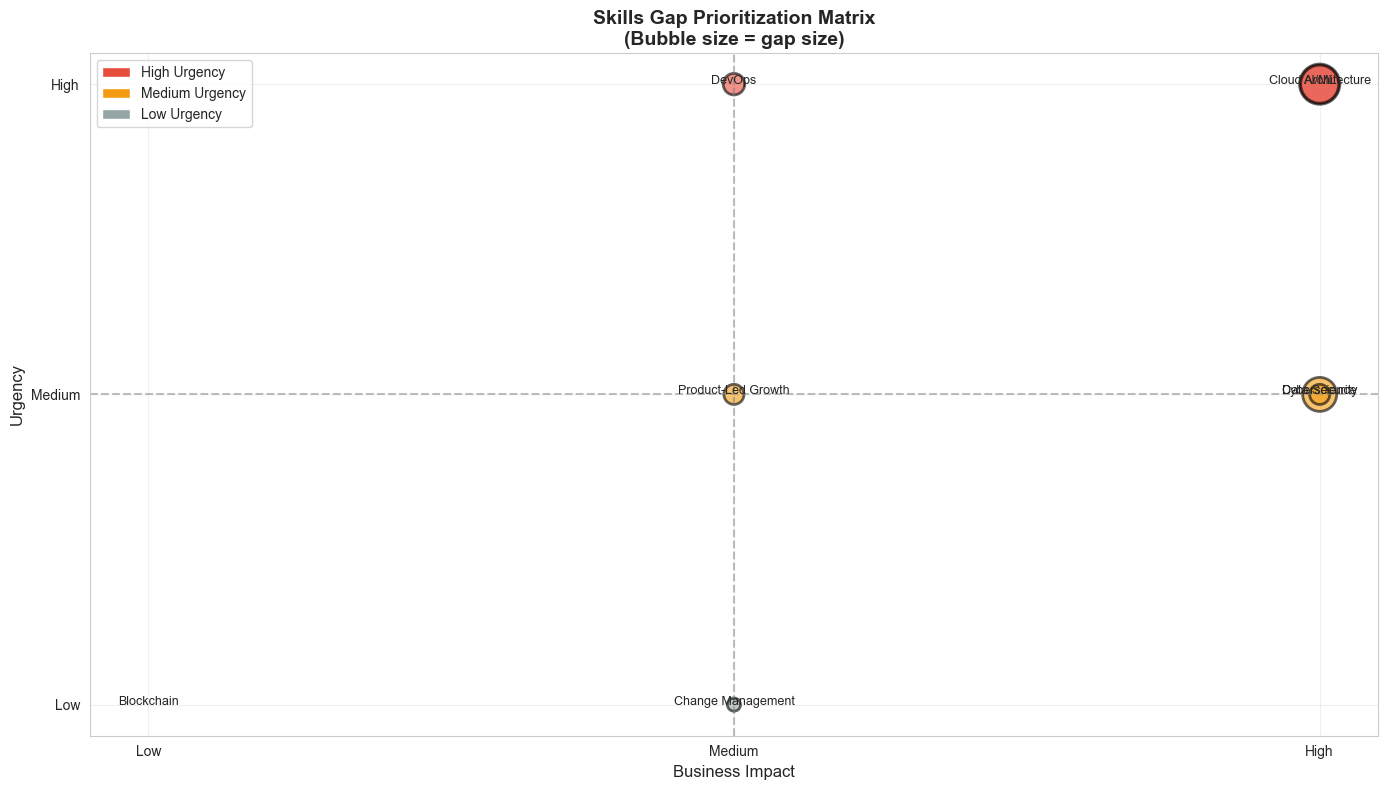

In [8]:
# Visualize skills gap with impact
fig, ax = plt.subplots(figsize=(14, 8))

# Bubble chart: gap size vs urgency/impact
impact_map = {'High': 3, 'Medium': 2, 'Low': 1}
urgency_map = {'High': 3, 'Medium': 2, 'Low': 1}

gap_df['impact_score'] = gap_df['business_impact'].map(impact_map)
gap_df['urgency_score'] = gap_df['urgency'].map(urgency_map)

# Color by urgency
color_map = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#95a5a6'}
colors = [color_map[u] for u in gap_df['urgency']]

scatter = ax.scatter(gap_df['impact_score'], gap_df['urgency_score'], 
                    s=gap_df['gap']*30, alpha=0.6, c=colors, edgecolors='black', linewidth=2)

# Add labels
for i, row in gap_df.iterrows():
    ax.annotate(row['skill'], 
               (row['impact_score'], row['urgency_score']),
               fontsize=9, ha='center')

ax.set_xlabel('Business Impact', fontsize=12)
ax.set_ylabel('Urgency', fontsize=12)
ax.set_title('Skills Gap Prioritization Matrix\n(Bubble size = gap size)', 
            fontsize=14, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['Low', 'Medium', 'High'])
ax.grid(alpha=0.3)

# Add quadrant shading
ax.axhline(2, color='gray', linestyle='--', alpha=0.5)
ax.axvline(2, color='gray', linestyle='--', alpha=0.5)

# Legend
legend_elements = [
    Patch(facecolor='#e74c3c', label='High Urgency'),
    Patch(facecolor='#f39c12', label='Medium Urgency'),
    Patch(facecolor='#95a5a6', label='Low Urgency')
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

## 5. Build vs. Buy Decision Framework

In [ ]:
# Build vs Buy decision factors
build_buy_analysis = []

for _, row in gap_df.iterrows():
    skill = row['skill']
    gap = row['gap']
    urgency = row['urgency']
    
    # Decision logic
    # High urgency + large gap = Buy (hire externally)
    # Low urgency + small gap = Build (train internally)
    # Medium = Hybrid
    
    if urgency == 'High' and gap > 20:
        recommendation = 'Buy (External Hiring)'
        rationale = 'High urgency, large gap - faster to hire'
        build_pct = 30
        buy_pct = 70
    elif urgency == 'Low' and gap < 15:
        recommendation = 'Build (Internal Development)'
        rationale = 'Low urgency, small gap - cost-effective to train'
        build_pct = 80
        buy_pct = 20
    else:
        recommendation = 'Hybrid (Build + Buy)'
        rationale = 'Combination of training and selective hiring'
        build_pct = 50
        buy_pct = 50
    
    build_buy_analysis.append({
        'skill': skill,
        'gap': gap,
        'recommendation': recommendation,
        'build_%': build_pct,
        'buy_%': buy_pct,
        'build_count': int(gap * build_pct / 100),
        'buy_count': int(gap * buy_pct / 100),
        'rationale': rationale
    })

build_buy_df = pd.DataFrame(build_buy_analysis)

print("\nBUILD VS. BUY RECOMMENDATIONS")
print("="*100)
print(f"{'Skill':<20} {'Gap':<6} {'Recommendation':<30} {'Build':<8} {'Buy':<8}")
print("="*100)
for _, row in build_buy_df.iterrows():
    print(f"{row['skill']:<20} {row['gap']:<6} {row['recommendation']:<30} {row['build_count']:<8} {row['buy_count']:<8}")
print("="*100)

total_build = build_buy_df['build_count'].sum()
total_buy = build_buy_df['buy_count'].sum()
print(f"\nTotal to develop internally: {total_build}")
print(f"Total to hire externally: {total_buy}")

print("\n\nRATIONALE BY STRATEGY:")
print("-"*100)
for _, row in build_buy_df.iterrows():
    print(f"{row['skill']:<20} → {row['rationale']}")

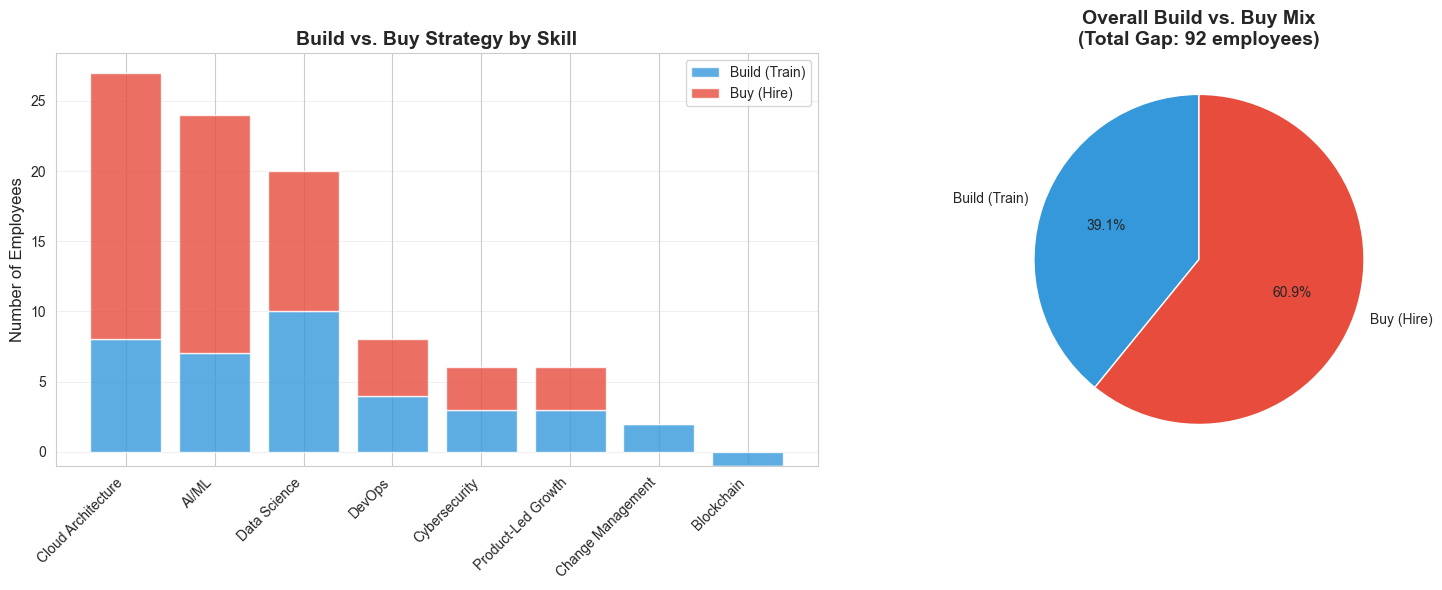

In [10]:
# Visualize build vs buy mix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar chart by skill
x = range(len(build_buy_df))
ax1.bar(x, build_buy_df['build_count'], label='Build (Train)', color='#3498db', alpha=0.8)
ax1.bar(x, build_buy_df['buy_count'], bottom=build_buy_df['build_count'], 
        label='Buy (Hire)', color='#e74c3c', alpha=0.8)

ax1.set_xticks(x)
ax1.set_xticklabels(build_buy_df['skill'], rotation=45, ha='right')
ax1.set_ylabel('Number of Employees', fontsize=12)
ax1.set_title('Build vs. Buy Strategy by Skill', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Pie chart: Overall build vs buy
ax2.pie([total_build, total_buy], labels=['Build (Train)', 'Buy (Hire)'],
        autopct='%1.1f%%', colors=['#3498db', '#e74c3c'], startangle=90)
ax2.set_title(f'Overall Build vs. Buy Mix\n(Total Gap: {total_build + total_buy} employees)', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Training & Development Plan

In [11]:
# Focus on "Build" recommendations
training_plan = build_buy_df[build_buy_df['build_count'] > 0].copy()
training_plan = training_plan.sort_values('build_count', ascending=False)

# Estimate training costs and timeline
avg_training_cost = 5000  # per person
avg_training_months = 6  # time to proficiency

training_plan['training_cost'] = training_plan['build_count'] * avg_training_cost
training_plan['timeline_months'] = avg_training_months

print("\nTRAINING & DEVELOPMENT PLAN")
print("="*80)
print(f"{'Skill':<20} {'# to Train':<12} {'Est. Cost':<15} {'Timeline':<15}")
print("="*80)
for _, row in training_plan.iterrows():
    print(f"{row['skill']:<20} {row['build_count']:<12} ${row['training_cost']:,<14} {row['timeline_months']} months")
print("="*80)
print(f"{'TOTAL':<20} {int(training_plan['build_count'].sum()):<12} ${int(training_plan['training_cost'].sum()):,<14}")
print("="*80)

print("\nTRAINING PROGRAM RECOMMENDATIONS:")
print("  1. Partner with online learning platforms (Coursera, Udemy, LinkedIn Learning)")
print("  2. Internal mentorship programs (pair learners with experts)")
print("  3. Lunch & learn sessions for knowledge sharing")
print("  4. Project-based learning (apply skills to real work)")
print("  5. External certifications and bootcamps for priority skills")


TRAINING & DEVELOPMENT PLAN
Skill                # to Train   Est. Cost       Timeline       
Data Science         10           $50000,,,,,,,,, 6 months
Cloud Architecture   8            $40000,,,,,,,,, 6 months
AI/ML                7            $35000,,,,,,,,, 6 months
DevOps               4            $20000,,,,,,,,, 6 months
Cybersecurity        3            $15000,,,,,,,,, 6 months
Product-Led Growth   3            $15000,,,,,,,,, 6 months
Change Management    2            $10000,,,,,,,,, 6 months
TOTAL                37           $185000,,,,,,,,

TRAINING PROGRAM RECOMMENDATIONS:
  1. Partner with online learning platforms (Coursera, Udemy, LinkedIn Learning)
  2. Internal mentorship programs (pair learners with experts)
  3. Lunch & learn sessions for knowledge sharing
  4. Project-based learning (apply skills to real work)
  5. External certifications and bootcamps for priority skills


## 7. Key Recommendations

In [12]:
print("\n" + "="*80)
print("KEY RECOMMENDATIONS")
print("="*80)

# Priority 1: Critical gaps
critical_gaps = gap_df[(gap_df['urgency'] == 'High') & (gap_df['business_impact'] == 'High')]
print("\n1. ADDRESS CRITICAL SKILLS GAPS IMMEDIATELY (High Impact + High Urgency)")
for _, row in critical_gaps.iterrows():
    strategy = build_buy_df[build_buy_df['skill'] == row['skill']].iloc[0]
    print(f"   → {row['skill']}: Hire {strategy['buy_count']}, Train {strategy['build_count']}")

# Priority 2: Training programs
print("\n2. LAUNCH TRAINING PROGRAMS (Q3 2026)")
top_training = training_plan.head(3)
for _, row in top_training.iterrows():
    print(f"   → {row['skill']}: {row['build_count']} employees, ${row['training_cost']:,} budget")

# Priority 3: Hiring strategy
print("\n3. SPECIALIZED HIRING CAMPAIGNS")
buy_priority = build_buy_df[build_buy_df['buy_count'] > 0].sort_values('buy_count', ascending=False).head(3)
for _, row in buy_priority.iterrows():
    print(f"   → Launch {row['skill']} hiring: {row['buy_count']} external hires")
    print(f"      Sources: LinkedIn, specialized recruiters, university partnerships")

# Priority 4: Budget
training_budget = training_plan['training_cost'].sum()
hiring_budget = total_buy * 25000  # $25K per external hire
total_budget = training_budget + hiring_budget

print("\n4. BUDGET REQUIREMENTS")
print(f"   → Training & Development: ${int(training_budget):,}")
print(f"   → External Hiring: ${int(hiring_budget):,} ({total_buy} hires @ $25K each)")
print(f"   → TOTAL SKILLS INVESTMENT: ${int(total_budget):,}")

print("\n" + "="*80)
print("Next Analysis: See '03_succession_planning.ipynb' to ensure")
print("critical roles have identified successors")
print("="*80)


KEY RECOMMENDATIONS

1. ADDRESS CRITICAL SKILLS GAPS IMMEDIATELY (High Impact + High Urgency)
   → Cloud Architecture: Hire 19, Train 8
   → AI/ML: Hire 17, Train 7

2. LAUNCH TRAINING PROGRAMS (Q3 2026)
   → Data Science: 10 employees, $50,000 budget
   → Cloud Architecture: 8 employees, $40,000 budget
   → AI/ML: 7 employees, $35,000 budget

3. SPECIALIZED HIRING CAMPAIGNS
   → Launch Cloud Architecture hiring: 19 external hires
      Sources: LinkedIn, specialized recruiters, university partnerships
   → Launch AI/ML hiring: 17 external hires
      Sources: LinkedIn, specialized recruiters, university partnerships
   → Launch Data Science hiring: 10 external hires
      Sources: LinkedIn, specialized recruiters, university partnerships

4. BUDGET REQUIREMENTS
   → Training & Development: $185,000
   → External Hiring: $1,400,000 (56 hires @ $25K each)
   → TOTAL SKILLS INVESTMENT: $1,585,000

Next Analysis: See '03_succession_planning.ipynb' to ensure
critical roles have identified